In [1]:
import pandas as pd
import sys
import importlib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split

importlib.reload(eda)
importlib.reload(visual)

<module 'visualization' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/visualization.py'>

In [4]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Exploratory Data Analysis
</h1>

In [5]:
# Columns Visualization
for column in dataset.columns:
    print(column)

Unnamed: 0
Marca
Modelo
Año
Versión
Color
Tipo de combustible
Puertas
Transmisión
Motor
Tipo de carrocería
Con cámara de retroceso
Kilómetros
Título
Precio
Moneda
Descripción
Tipo de vendedor


In [6]:
# Shape of the dataset
print(f"Cantidad de filas: {dataset.shape[0]}")
print(f"Cantidad de columnas: {dataset.shape[1]}")

Cantidad de filas: 18254
Cantidad de columnas: 18


In [7]:
TARGET = "Precio"

X = dataset.drop(columns = [TARGET])
y = dataset[TARGET]

In [8]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Label Analysis
</h3>

In [9]:
target_summary = eda.explore_target(y, currency = X["Moneda"])
display(target_summary)

,group,count,missing,missing_%,min,q1,median,mean,q3,max,std,zero_count
0,All,18254,0,0.0,111.0,31900.0,17200000.0,1.760162e+07,29950000.0,349500000.0,1.720810e+07,0
1,$,11158,0,0.0,119000.0,19000000.0,27320000.0,2.877461e+07,35900000.0,349500000.0,1.277861e+07,0
2,US$,7096,0,0.0,111.0,16000.0,24000.0,3.281019e+04,38900.0,610000.0,2.885445e+04,0


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Analysis
</h3>

In [10]:
# Explore Dataset Features
feature_summary = eda.explore_features(X)

display(feature_summary["numeric"])
display(feature_summary["categorical"])

,feature,dtype,non_missing,missing,missing_%,min,max,mean,median,std,q1,q3,zero_count,outlier_count,outlier_%,unique,unique_%
0,Año,float64,18254,0,0.0,1981.0,436694.0,2042.796209,2019.0,3217.260996,2016.0,2024.0,0,260,1.42,40,0.22
1,Puertas,float64,18254,0,0.0,2.0,60252.0,18.167306,5.0,891.766121,5.0,5.0,0,523,2.87,7,0.04


,feature,dtype,categories_preview,most_frequent,most_frequent_count,most_frequent_%,least_frequent_preview,rare_categories,missing,missing_%,non_missing,unique,unique_%
0,Marca,str,Ford: 2161 | Jeep: 2050 | Volkswagen: 2037 | Chevrolet: 1750 | Renault: 1491,Ford,2161,11.84,Range Rover: 1 | Rrenault: 1 | Jetur: 1 | hiunday: 1 | Vol: 1,5,0,0.00,18254,47,0.26
1,Modelo,str,Ecosport: 1569 | Tracker: 1511 | 2008: 1144 | Duster: 1048 | Compass: 916,Ecosport,1569,8.60,Tiggo 8 Pro: 2 | Clase GL: 2 | DS3: 2 | Mohave: 2 | F-PACE: 2,0,0,0.00,18254,137,0.75
2,Versión,str,1.6 Exclusive Cvt: 320 | 1.4 250 Tsi Comfortline: 261 | 1.4 250 Tsi Highline: 255 | 1.8 Ltz+ Awd At 140cv: 213 | 1.2...,1.6 Exclusive Cvt,320,1.75,2.0 Hse 4 At: 1 | 2.7 4WD V6: 1 | 2.0 GLC300 4MATIC COUPE AMG-LINE: 1 | 1.8 Awd Ltz At: 1 | Trendline 200 Tsi Automa...,1038,0,0.00,18254,2072,11.35
3,Color,str,Gris: 5468 | Blanco: 4809 | Negro: 2825 | Plateado: 1427 | Azul: 1121,Gris,5468,29.96,GRIS SILVERSTONE: 1 | GRANITE CRYSTA BC: 1 | SKYSCRAPER GRAU METALLIC: 1 | BLANCO BANCHISA BICOLOR NEGRO: 1 | GRIS P...,32,389,2.13,17865,70,0.38
4,Tipo de combustible,str,Nafta: 16067 | Diésel: 1328 | Nafta/GNC: 451 | Híbrido/Nafta: 269 | Híbrido: 105,Nafta,16067,88.02,Mild Hybrid: 10 | Eléctrico: 12 | GNC: 12 | Híbrido: 105 | Híbrido/Nafta: 269,0,0,0.00,18254,8,0.04
5,Transmisión,str,Automática: 12281 | Manual: 5834 | Automática secuencial: 123 | Semiautomática: 1,Automática,12281,67.28,Semiautomática: 1 | Automática secuencial: 123 | Manual: 5834 | Automática: 12281,1,15,0.08,18239,4,0.02
6,Motor,str,1.6: 4132 | 2.0: 3121 | 1.8: 1749 | 1.0: 1417 | 1.3: 1079,1.6,4132,22.64,T270 1.3T: 1 | Nafta / Electrico: 1 | 1.5turbo: 1 | 3.0 biturbo 440cv: 1 | 2.5 Híbrido: 1,159,38,0.21,18216,271,1.48
7,Tipo de carrocería,str,SUV: 18254,SUV,18254,100.00,SUV: 18254,0,0,0.00,18254,1,0.01
8,Con cámara de retroceso,str,Sí: 3731 | No: 960,Sí,3731,20.44,No: 960 | Sí: 3731,0,13563,74.30,4691,2,0.01
9,Kilómetros,str,0.0: 4237 | 0 km: 324 | 1000.0: 220 | 90000.0: 194 | 120000.0: 194,0.0,4237,23.21,54.000 km: 1 | 63.000 km: 1 | 83.000 km: 1 | 60.000 km: 1 | 40.000 km: 1,1362,0,0.00,18254,2175,11.92


In [11]:
eda.duplicate_rows_summary(dataset)

,total_rows,duplicate_rows
0,18254,0


In [12]:
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
11,Con cámara de retroceso,13563,74.30
5,Color,389,2.13
9,Motor,38,0.21
8,Transmisión,15,0.08


In [13]:
eda.unique_values_summary(dataset)

,column,unique_values,unique_pct
0,Unnamed: 0,18254,100.00
16,Descripción,12142,66.52
14,Precio,2914,15.96
13,Título,2220,12.16
12,Kilómetros,2175,11.92
4,Versión,2072,11.35
9,Motor,271,1.48
2,Modelo,137,0.75
5,Color,70,0.38
1,Marca,47,0.26


In [ ]:
categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de combustible",
    "Transmisión",
    "Tipo de vendedor",
]

semantic_repetitions = eda.find_semantic_repetitions(dataset, columns = categorical_columns, similarity_threshold=0.80)

semantic_repetitions

,feature,similar_values,normalized_values,total_count,n_values_grouped
0,Color,Blanco | Blanca | BLANCA | blanca,blanca | blanco,4818,4
1,Color,Negro | Negra | NEGRA,negra | negro,2830,3
2,Color,Dorado | MORADO,dorado | morado,191,2
3,Color,Amarillo | Amarrillo,amarillo | amarrillo,25,2
4,Color,Plata | PLATA,plata,9,2
5,Color,Gris plata | GRIS PLATA | GRIS PLATINO,gris plata | gris platino,5,3
6,Color,Marrón oscuro | Marrón claro,marron claro | marron oscuro,3,2
7,Color,Blanco Glaciar | BLANCO GLACIAR,blanco glaciar,2,2
8,Color,GRANITE CRYSTAL BC | GRANITE CRYSTA BC,granite crysta bc | granite crystal bc,2,2
9,Marca,Renault | Rrenault,renault | rrenault,1492,2


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Initial Graphics Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Data Quality
</div>

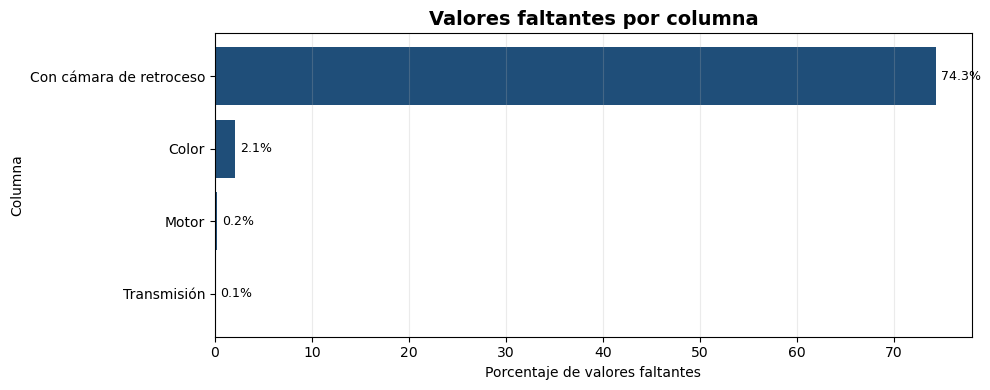

In [15]:
visual.plot_missing_values(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Categorical Variables
</div>

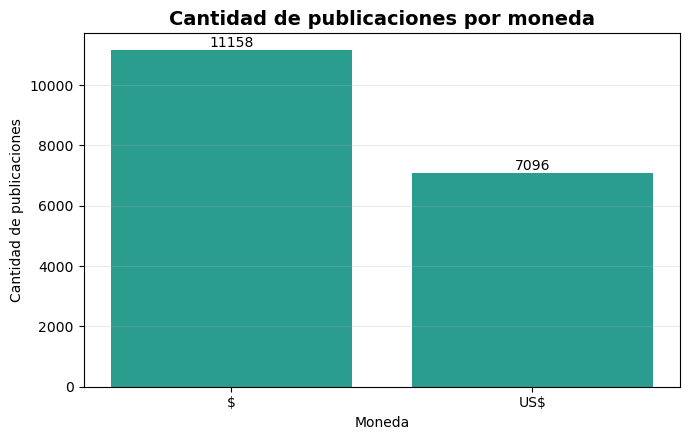

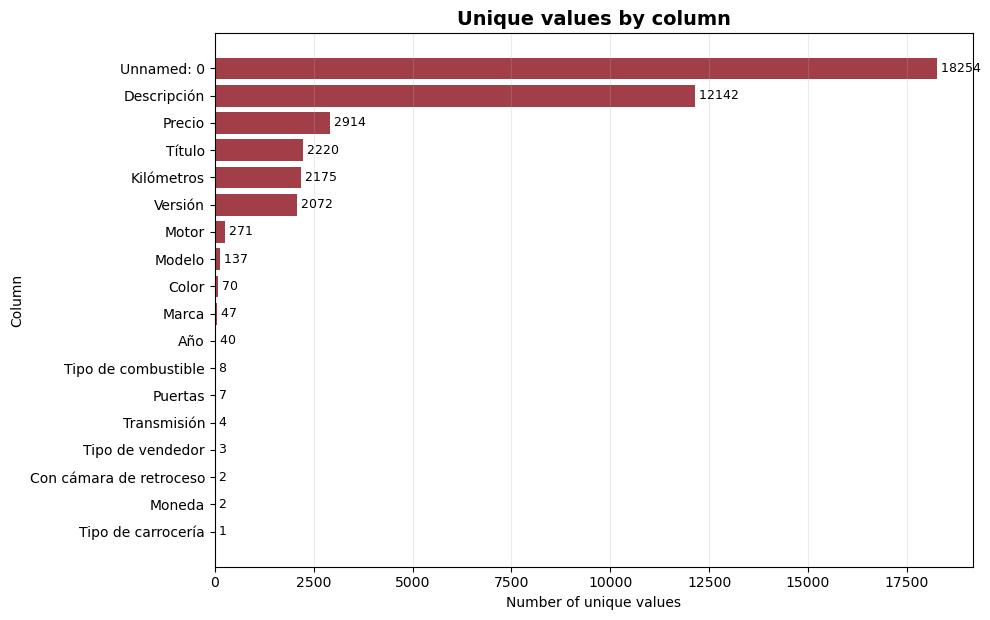

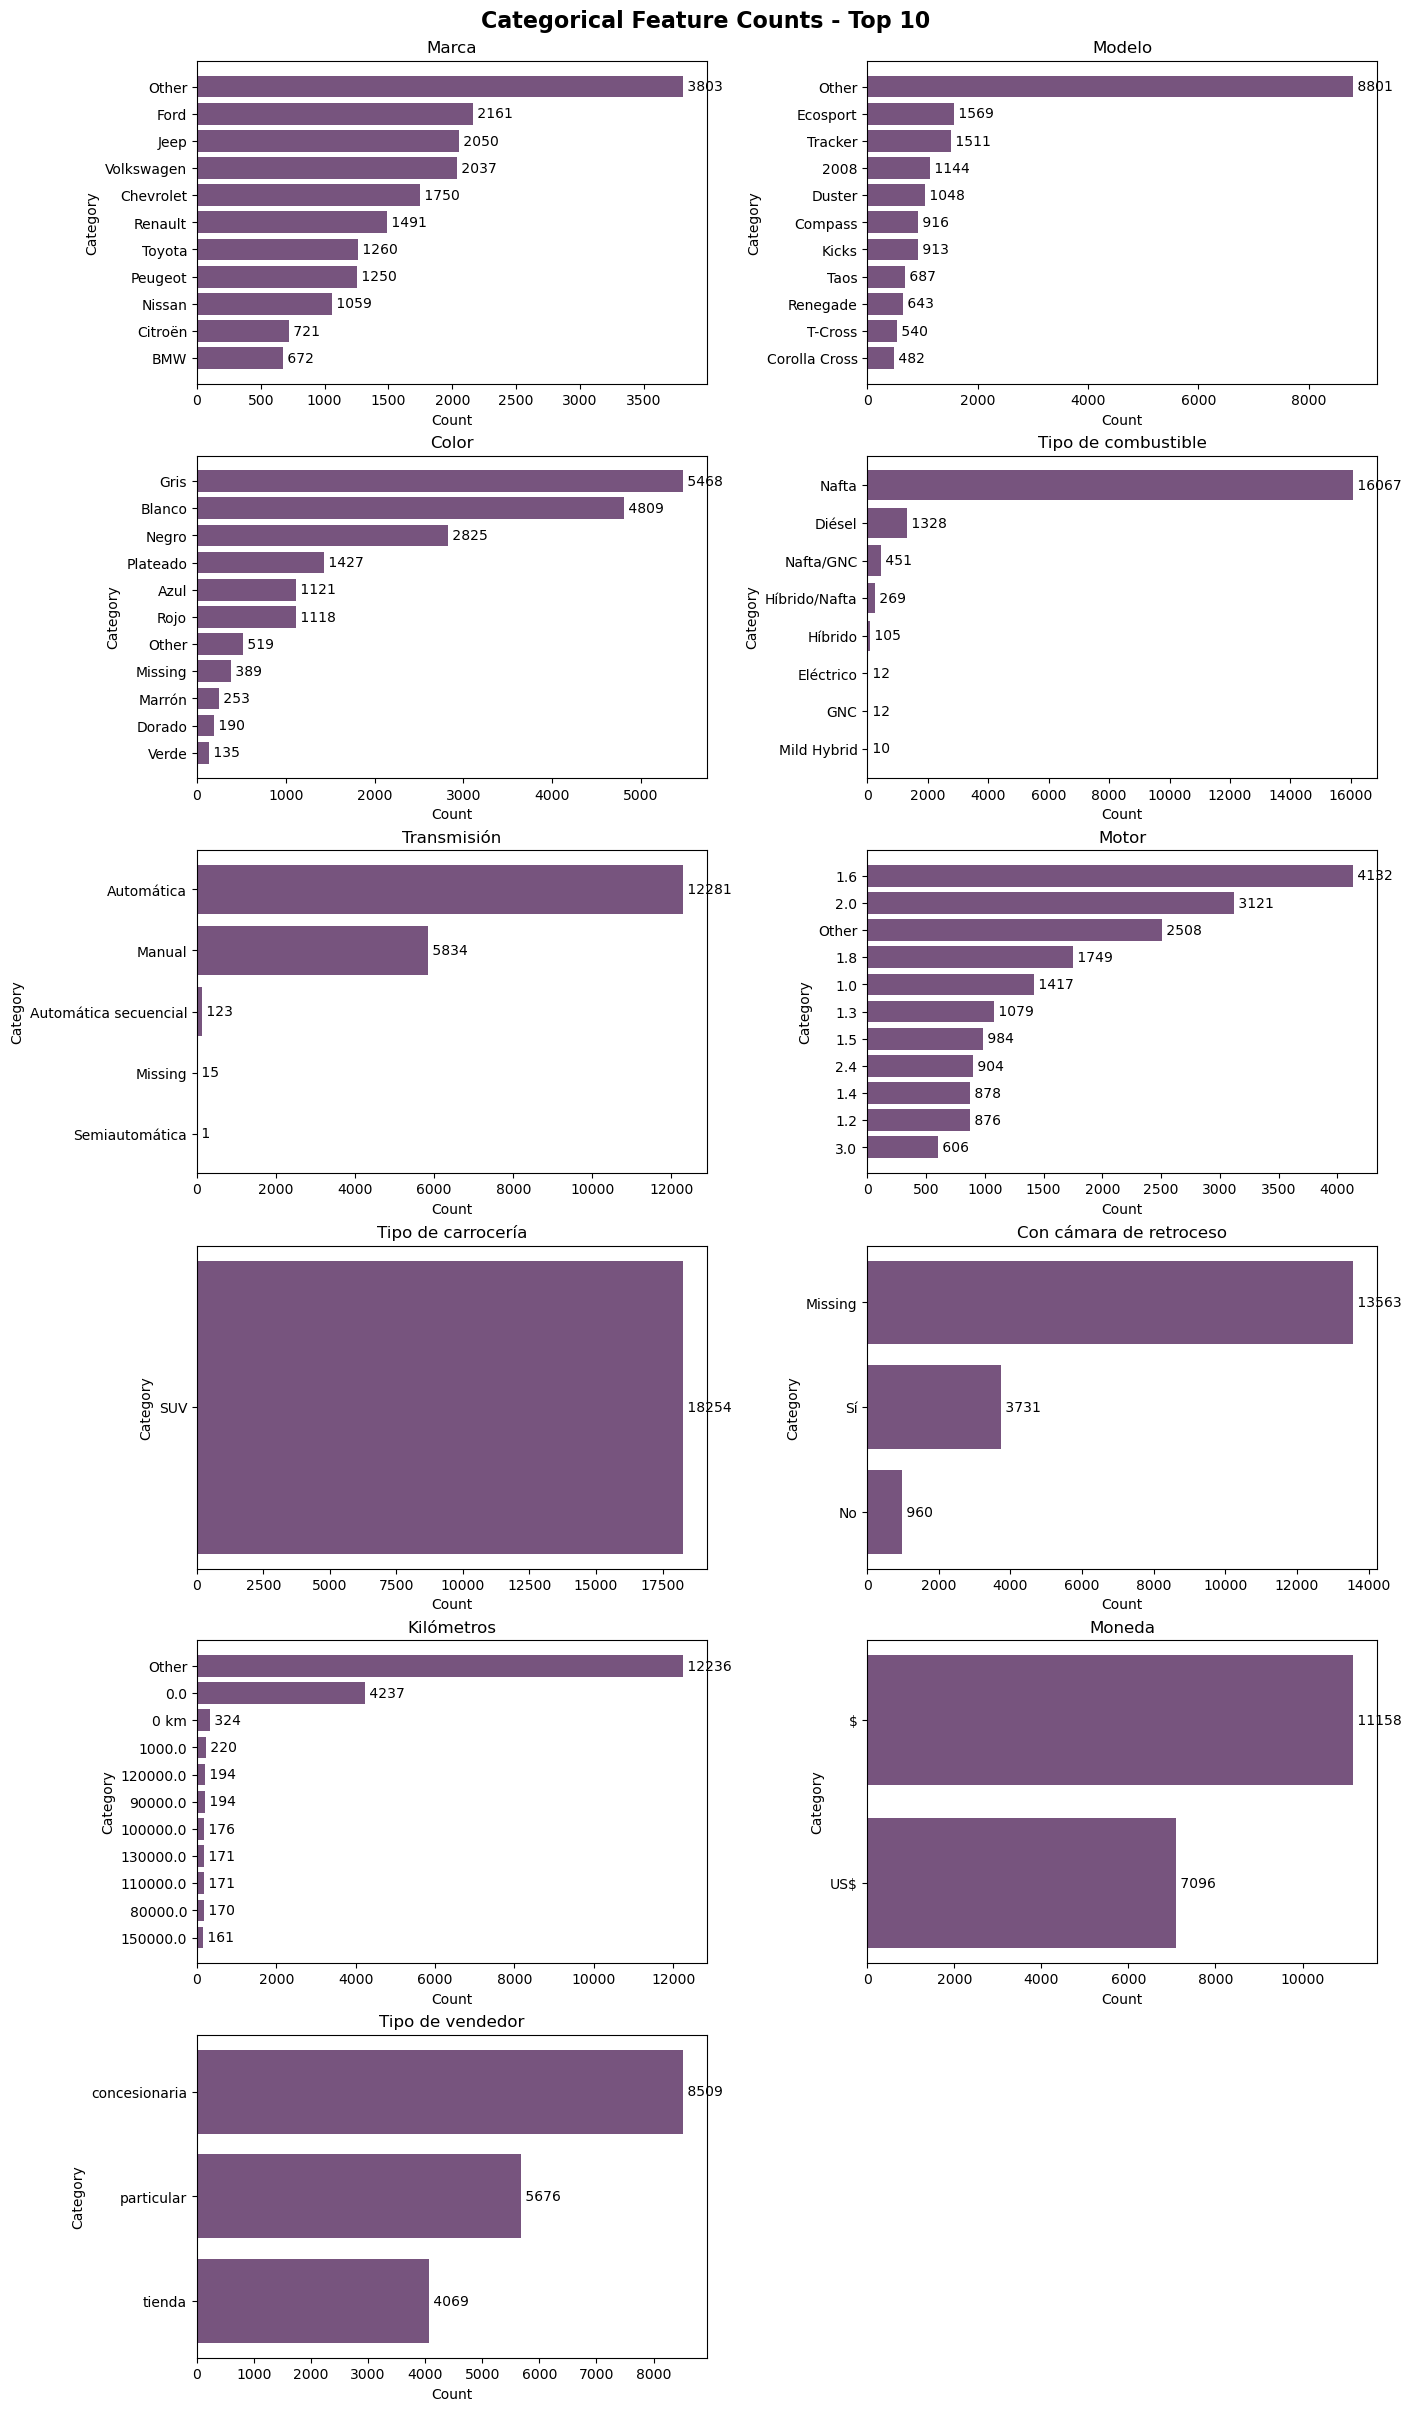

In [16]:
visual.plot_currency_counts(dataset)
visual.plot_unique_values(dataset)
visual.plot_categorical_counts(X, ignored_columns=["Título", "Descripción", "Versión"], top_n = 10, n_cols = 2)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numerical Variables
</div>

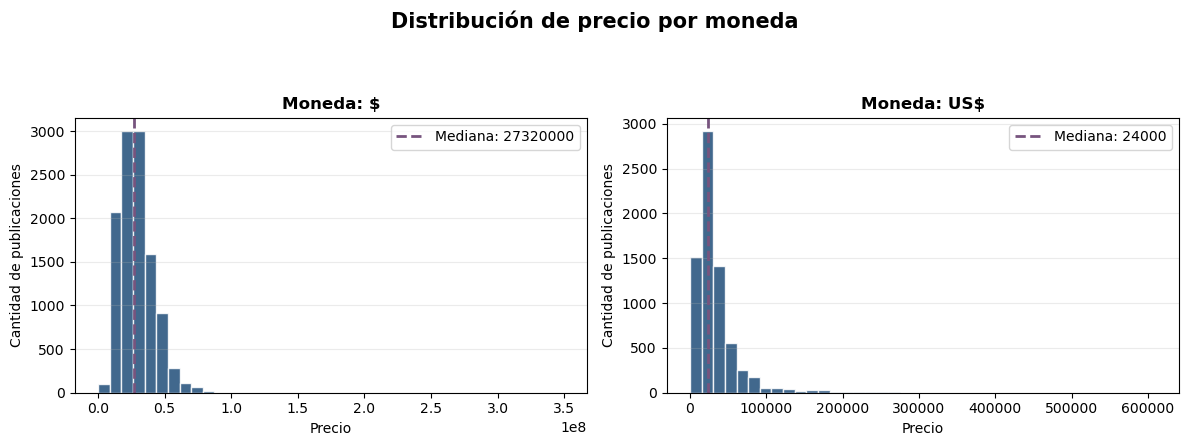

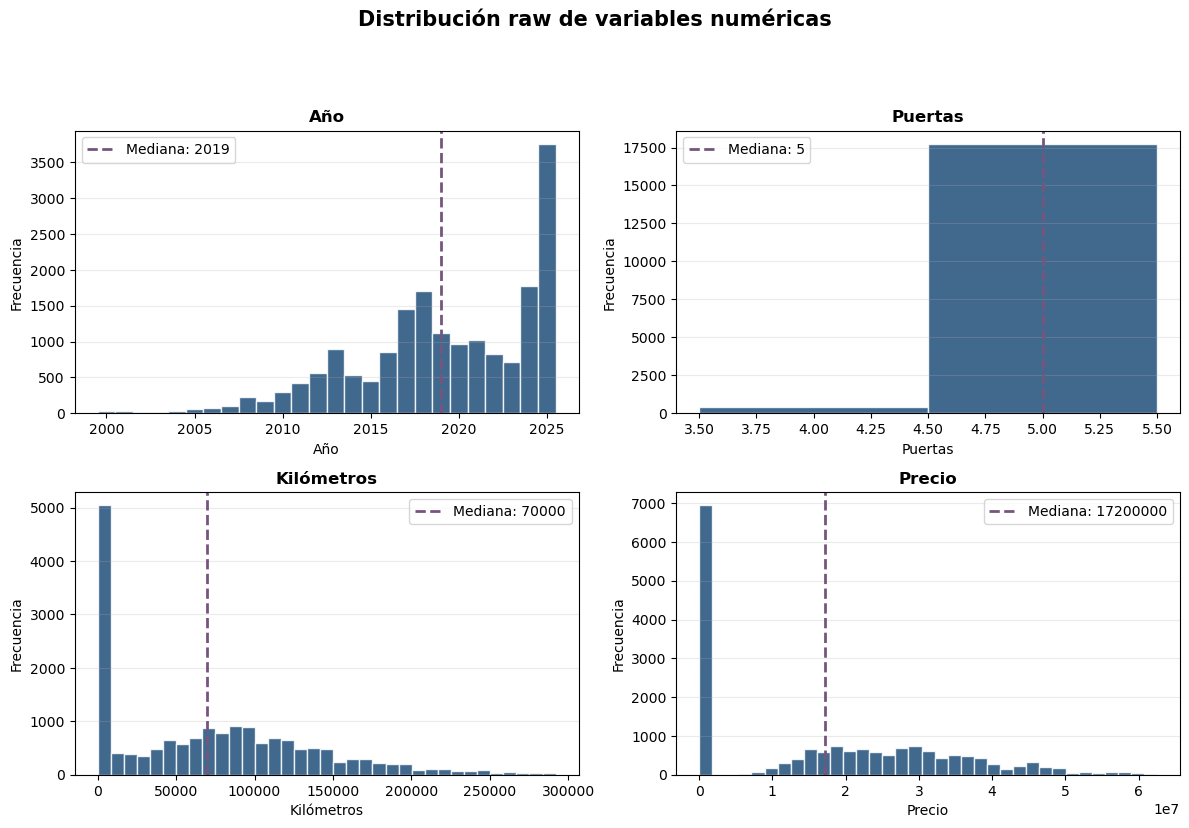

In [17]:
visual.plot_price_distribution_by_currency(dataset)
visual.plot_raw_numeric_distributions(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Preliminary Outlier Detection
</div>

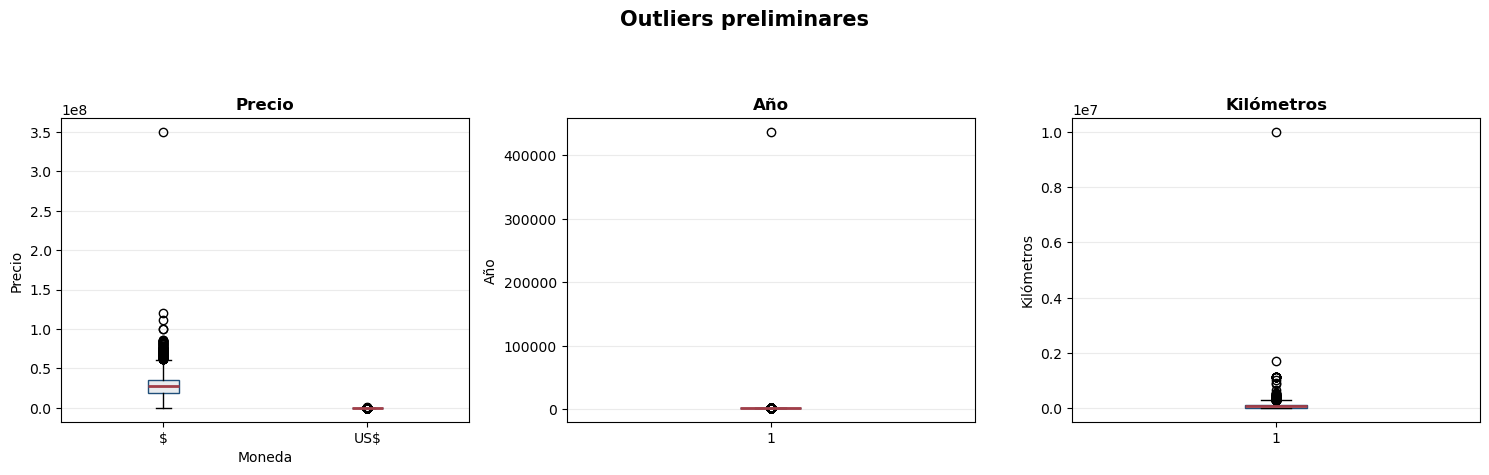

In [18]:
visual.plot_preliminary_outliers(dataset)

En las distribuciones raw se observan algunos valores claramente atípicos que afectan la forma de los gráficos. Por ejemplo, en `Año` aparece un valor imposible y en `Puertas` hay registros con cantidades extremadamente altas. Estos valores hacen que el eje del histograma se estire mucho y que la mayor parte de las observaciones reales quede comprimida en una sola zona.

Por eso, para visualizar mejor las distribuciones, se filtraron los valores extremos solo al momento de graficar, usando percentiles. Esto no implica eliminar datos todavía, sino simplemente evitar que unos pocos outliers deformen el gráfico. La limpieza o corrección definitiva de estos valores se realizará más adelante durante el preprocesamiento.

Con este chequeo se detectan valores incoherentes en dos variables. En `Año` aparece una observación con valor `436694`, claramente mayor al año actual, por lo que se trata de un error de carga. Además, en `Puertas` se observa un valor máximo de `60252`, con 4 observaciones que tienen más de 7 puertas, lo cual tampoco es razonable para este tipo de vehículos.

Como estos casos son pocos y corresponden a valores no interpretables, se podrian eliminar directamente en el preprocesamiento

<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [19]:
dataset_processed = eda.drop_irrelevant_columns(dataset, columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [20]:
constant_columns = eda.get_constant_columns(dataset_processed)
constant_columns

,column,unique_value
0,Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [21]:
dataset_processed = eda.drop_irrelevant_columns(dataset, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

In [22]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


El chequeo muestra que existe una observación con un valor de **`Año`** igual a **436694**, lo cual no es interpretable como año de fabricación del vehículo.

Además, la variable **`Puertas`** presenta un valor máximo de **60252**, y se detectan observaciones con más de 5 puertas. Dado que estos valores no son razonables para vehículos SUV, se consideran inconsistencias del dataset y se eliminan antes del entrenamiento de los modelos.

In [23]:
range_rules = {
    "Año": {"max": 2025},
    "Puertas": {"max": 5},
}

dataset_processed = eda.remove_invalid_values(dataset_processed, range_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en la misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares, se convierten los precios en pesos a dólares estadounidenses.

Como tipo de cambio se utiliza el promedio entre el valor del dólar oficial del Banco Nación a principio y a fin de mayo de 2024, año y mes en el cual el dataset fue creado.

In [24]:
EXCHANGE_RATE = (895.25 + 913) / 2
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE}")

El tipo de cambio utilizado es de $904.125


In [25]:
dataset_processed = eda.convert_peso_prices_to_usd(dataset_processed, exchange_rate = EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta sección buscamos limpiar y unificar categorías que representan lo mismo pero aparecen escritas de distintas formas. Por ejemplo, diferencias de mayúsculas, tildes, guiones, espacios o variantes como `Blanco`, `blanco` y `Blanca`.

Antes de aplicar cambios, en la sección de análisis de variables categóricas se revisaron las categorías disponibles y se exploró la similitud entre valores de columnas con posibles repeticiones semánticas, como `Color`, `Marca`, `Modelo`, `Transmisión` y `Motor`. A partir de ese análisis decidimos qué variables conviene limpiar manualmente y cuáles requieren más cuidado para no unir categorías que en realidad representan cosas distintas.

Para esto usamos una estrategia semi-automática: primero normalizamos los textos y calculamos similitud entre categorías para detectar posibles repeticiones. Luego revisamos esos grupos antes de aplicar un mapeo manual. Esta decisión evita unir categorías incorrectamente.

Para el caso de `Color` y `Marca` se decidió hacer el mapeo a mano, ya que tienen una cantidad manejable de categorías y el criterio manual permite mayor control.

<div style="
    text-align: center;
    background-color: rgba(180, 170, 170, 0.1);
    color: white;
    padding: 5px;
    border-radius: 6px;
    font-weight:;
">
Looking for Similarities
</div>

In [63]:
BRAND_MAP = {
    "renault": ["renault", "rrenault"],
    "jetour": ["jetur", "jetour"],
    "hyundai": ["hiunday", "hyundai"],
    "volkswagen": ["volkswagen", "vol"],
    "ds": ["ds", "d.s.", "d·s", "ds automobiles"],
    "land rover": ["range rover", "land rover"],
    "great wall motor": ["gwm", "gwm", "haval"]
}

MODEL_MAP = {
    "sw4": ["sw4", "hilux sw4"],
    "ds7": ["ds7", "ds7 crossback"],
    "clase ml": ["clase ml", "ml"],
    "q5 sportback": ["q5 sportback"],
    "santa fe": ["santa fe", "grand santa fe", "grand santa fé"],
    "tiggo 4": ["tiggo 4", "tiggo 4 pro"],
}

COLOR_MAP = {
    "blanco": ["blanca", "blanco", "blanco glaciar", "summit white", "mineralweiss metallic", "blanco nacre tricapa", "blanco banquise", "blanco banchisa bicolor negro"],
    "negro": ["negra", "negro", "carbon black", "black meet kettle", "noir perla nera"],
    "amarillo": ["amarilla", "amarillo", "amarrillo"],
    "dorado": ["dorada", "dorado", "champaing"],
    "gris": ["gris", "gris plata", "gris platino", "plata", "plateado", "gray", "gris laque", "plata bari", "prata bari+tet vulc", "gris estrella", "gris artense"],
    "gris oscuro": ["gris oscuro", "gris selenium", "grafito", "granite crystal bc", "granite crysta bc", "gris titane", "gris indy", "gris silverstone", "skyscraper grau metallic"],
    "marron": ["marron claro", "marron oscuro", "cafe", "marron kodiak"],
    "azul": ["azul", "steel blue", "blue"],
    "rojo": ["rojo", "rojo sunset metalizado"],
    "verde": ["verde", "verde oscuro"],
    "beige": ["beige", "beige techo negro"],
    "celeste": ["celeste", "azul claro"],
    "naranja": ["naranja", "cobre"],
    "violeta": ["violeta", "morado", "morado oscuro"],
    "bordo": ["bordo"],
    "rosa": ["rosa"],
    "otros": ["otro", "acero", "rosa", "moundaz", "cendre"]
}

In [64]:
dataset_processed = eda.apply_semantic_mapping(dataset_processed, column = "Marca", 
                                               category_map = BRAND_MAP)

dataset_processed = eda.apply_semantic_mapping(dataset_processed, column = "Modelo", 
                                               category_map = MODEL_MAP)

dataset_processed = eda.apply_semantic_mapping(dataset_processed, column = "Color", 
                                               category_map = COLOR_MAP)

In [28]:
dataset_processed["Marca"].value_counts()

Marca
ford                2161
jeep                2049
volkswagen          2036
chevrolet           1750
renault             1492
toyota              1256
peugeot             1250
nissan              1059
citroen              721
bmw                  670
honda                596
hyundai              571
audi                 529
fiat                 366
chery                344
kia                  290
mercedes benz        282
dodge                185
baic                 165
suzuki                76
porsche               67
land rover            66
mitsubishi            47
volvo                 38
ds                    33
ssangyong             30
alfa romeo            25
jac                   19
great wall motor      18
jetour                15
isuzu                  8
lifan                  7
lexus                  7
subaru                 5
daihatsu               4
mini                   3
kaiyi                  2
jaguar                 2
Name: count, dtype: int64

In [65]:
dataset_processed["Modelo"].value_counts()

Modelo
ecosport       1569
tracker        1511
2008           1144
duster         1048
compass         916
               ... 
tiggo 8 pro       2
clase gl          2
ds3               2
mohave            2
f pace            2
Name: count, Length: 132, dtype: int64

In [29]:
dataset_processed["Color"].value_counts()

Color
gris           6910
blanco         4825
negro          2833
azul           1124
rojo           1119
missing         388
marron          260
dorado          191
verde           137
beige           126
celeste          95
naranja          74
gris oscuro      53
violeta          35
bordo            29
amarillo         25
otros            20
Name: count, dtype: int64

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Algunas variables categóricas representan información binaria, es decir, valores de tipo **sí/no**. Para que puedan ser utilizadas por los modelos predictivos, estas variables deben transformarse a una representación numérica.

En este caso, la variable **`Con cámara de retroceso`** se codifica como:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [30]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = eda.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

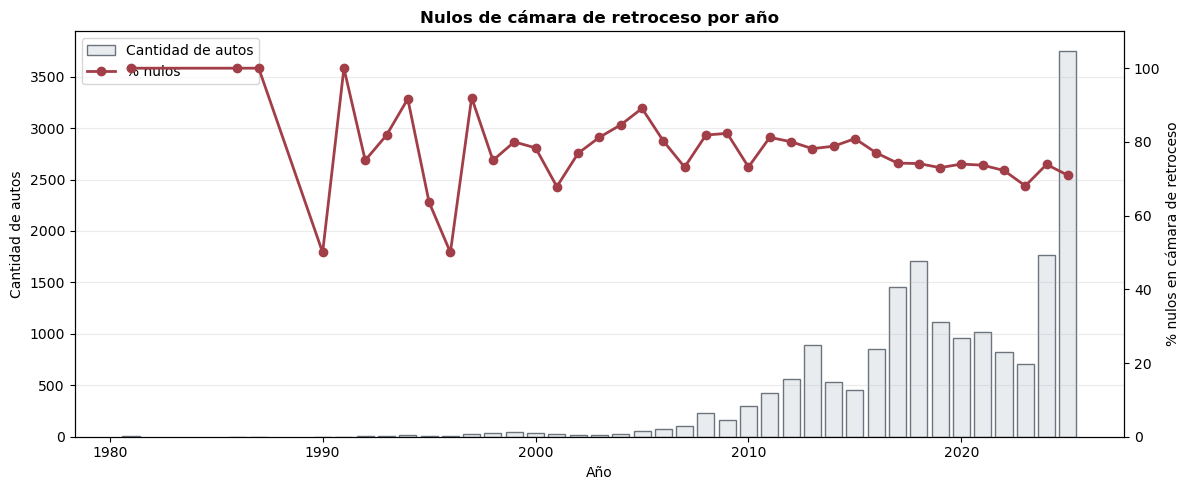

,Año,total,missing,missing_pct
0,1981,3,3,100.000000
1,1986,1,1,100.000000
2,1987,1,1,100.000000
3,1990,2,1,50.000000
4,1991,2,2,100.000000
5,1992,4,3,75.000000
6,1993,11,9,81.818182
7,1994,12,11,91.666667
8,1995,11,7,63.636364
9,1996,8,4,50.000000


In [31]:
camera_missing_by_year = visual.plot_camera_missing_by_year(dataset_processed)
camera_missing_by_year

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [32]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [34]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set